## **Importing Libraries**

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## **Loading Dataset**

In [5]:
df=pd.read_csv(r"D:\DS (project)\Python_Diwali_Sales_Analysis\Diwali Sales Data.csv",encoding="unicode_escape")

## **Dataset Overview (Initial Exploration)**


In [6]:
df.shape

(11251, 15)

In [7]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [8]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount', 'Status', 'unnamed1'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11251 entries, 0 to 11250
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   User_ID           11251 non-null  int64  
 1   Cust_name         11251 non-null  object 
 2   Product_ID        11251 non-null  object 
 3   Gender            11251 non-null  object 
 4   Age Group         11251 non-null  object 
 5   Age               11251 non-null  int64  
 6   Marital_Status    11251 non-null  int64  
 7   State             11251 non-null  object 
 8   Zone              11251 non-null  object 
 9   Occupation        11251 non-null  object 
 10  Product_Category  11251 non-null  object 
 11  Orders            11251 non-null  int64  
 12  Amount            11239 non-null  float64
 13  Status            0 non-null      float64
 14  unnamed1          0 non-null      float64
dtypes: float64(3), int64(4), object(8)
memory usage: 1.3+ MB


In [10]:
df.describe()

,User_ID,Age,Marital_Status,Orders,Amount,Status,unnamed1
count,1.125100e+04,11251.000000,11251.000000,11251.000000,11239.000000,0.0,0.0
mean,1.003004e+06,35.421207,0.420318,2.489290,9453.610858,NaN,NaN
std,1.716125e+03,12.754122,0.493632,1.115047,5222.355869,NaN,NaN
min,1.000001e+06,12.000000,0.000000,1.000000,188.000000,NaN,NaN
25%,1.001492e+06,27.000000,0.000000,1.500000,5443.000000,NaN,NaN
50%,1.003065e+06,33.000000,0.000000,2.000000,8109.000000,NaN,NaN
75%,1.004430e+06,43.000000,1.000000,3.000000,12675.000000,NaN,NaN
max,1.006040e+06,92.000000,1.000000,4.000000,23952.000000,NaN,NaN


## **Data Cleaning**

### **Removing Columns with Excessive Missing Values**


In [11]:
df.drop(['Status', 'unnamed1'],axis=1,inplace=True)

### **Count of Null values**

In [12]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

### **Removing Other Remaining Null Values**

In [13]:
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

### **Changing Datatype of column Amount**

In [15]:
df["Amount"]=df["Amount"].astype(int)

## **Exploratory Data Analysis**

### **Gender Distribution of Customers**


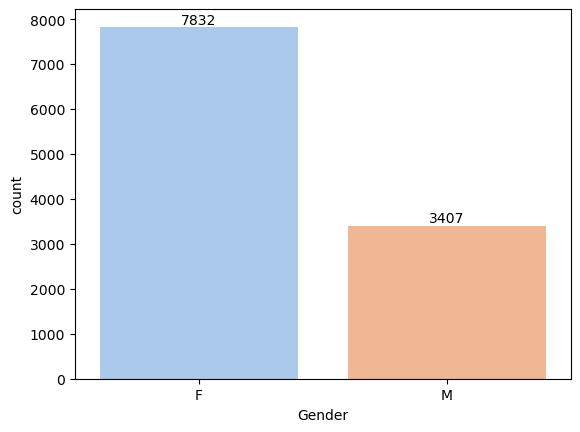

In [16]:
gender=sns.countplot(x="Gender",data=df,hue="Gender",palette="pastel")
for bars in gender.containers:
    gender.bar_label(bars)

#### The bar chart shows the distribution of customers by gender. It can be observed that the number of female customers is higher than male customers, indicating that female customers form the majority of the customer base.

### **Total Sales by Gender**


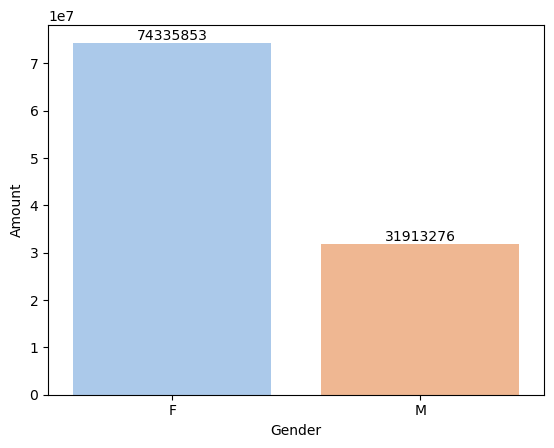

In [17]:
sales_gen=df.groupby(["Gender"],as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)
graph=sns.barplot(x="Gender",y="Amount",hue="Gender",palette="pastel",data=sales_gen)
for bars in graph.containers:
    graph.bar_label(bars, fmt='%.0f')

#### The bar chart shows total sales by gender. It is observed that female customers have contributed more to total sales than male customers, meaning females are the top contributors to revenue.

### **Age Group vs Gender Distribution**


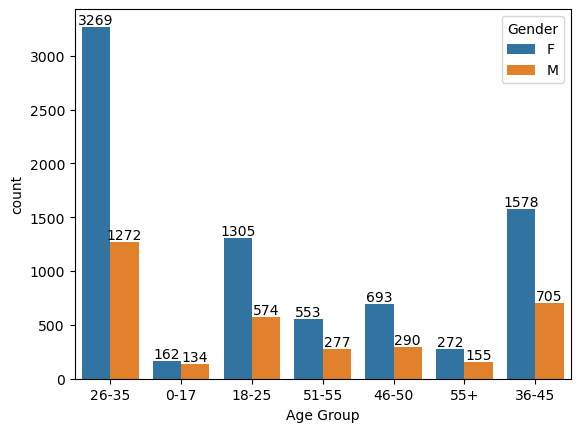

In [18]:
age_gen=sns.countplot(x="Age Group",hue="Gender",data=df)
for bars in age_gen.containers:
    age_gen.bar_label(bars)

#### The bar chart shows the distribution of customers by Age Group and Gender. It can be observed that in most age groups, female customers outnumber male customers, indicating that females form the majority in the customer base across different age ranges.

### **Total Sales by Age Group**


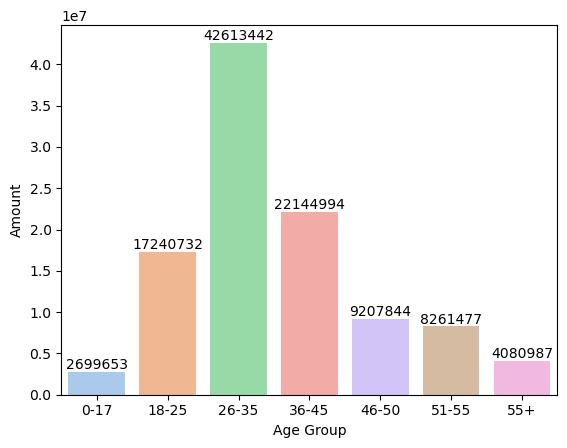

In [19]:
sales_age=df.groupby(["Age Group"],as_index=False)["Amount"].sum().sort_values(by="Age Group",ascending=True)
age_group=sns.barplot(x="Age Group",y="Amount",data=sales_age,hue="Age Group", palette="pastel")
for bars in age_group.containers:
    age_group.bar_label(bars,fmt="%.0f")

#### The bar chart shows total sales amount for each Age Group. It can be observed that the 26–35 age group has the highest total sales, indicating that customers in this age range contribute the most to the revenue.

### **Top 10 States by Total Number of Orders**

<Axes: xlabel='State', ylabel='Orders'>

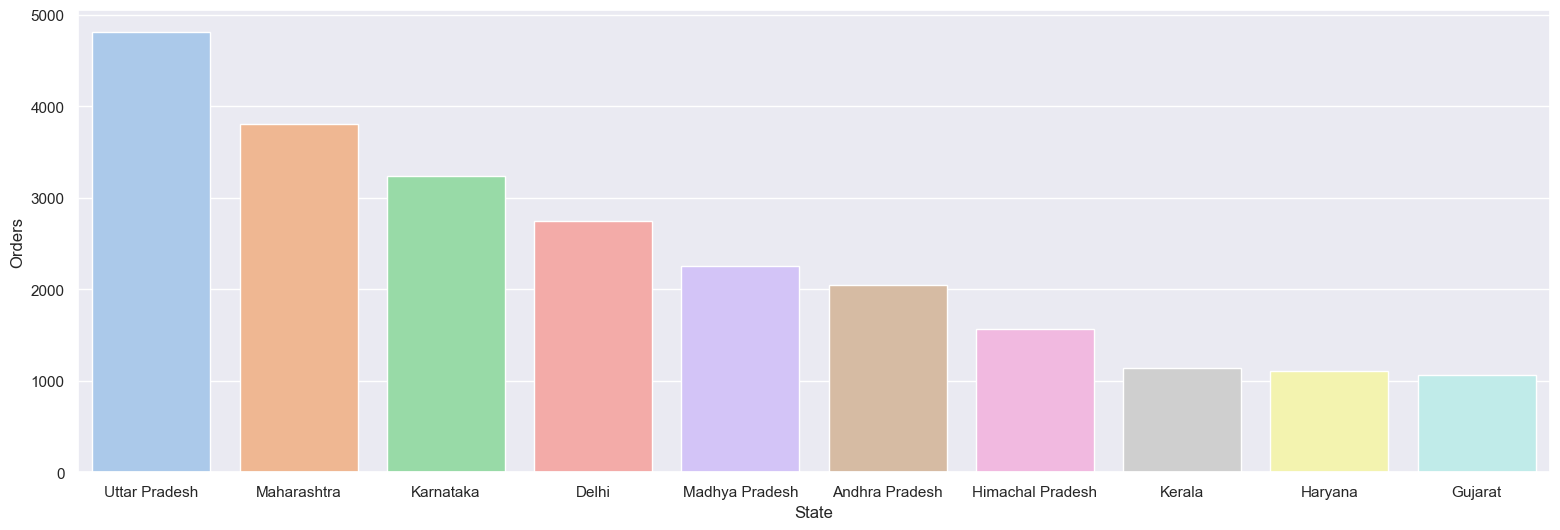

In [29]:
state_order=df.groupby(["State"],as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False).head(10)
sns.set(rc={"figure.figsize":(19,6)})
sns.barplot(x="State",y="Orders",data=state_order,hue="State",palette="pastel")

#### Uttar Pradesh has the highest number of orders among all states, indicating that it is the largest contributing state to overall sales.

### **Distribution of Customers by Marital Status**

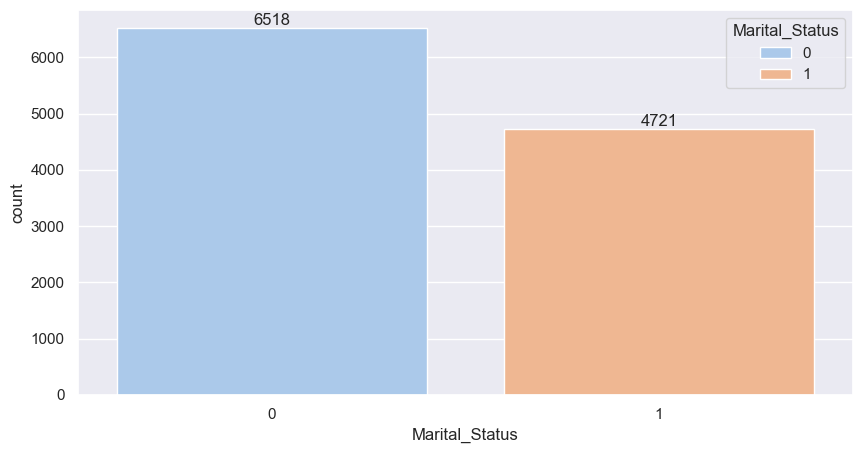

In [40]:
gender=sns.countplot(x="Marital_Status",data=df,hue="Marital_Status",palette="pastel")
sns.set(rc={"figure.figsize":(10,3)})
for bars in gender.containers:
    gender.bar_label(bars)

#### The bar chart shows that the majority of customers are unmarried (0), indicating that this marital group has the highest representation in the dataset.

### **Total Sales Amount by Marital Status and Gender**

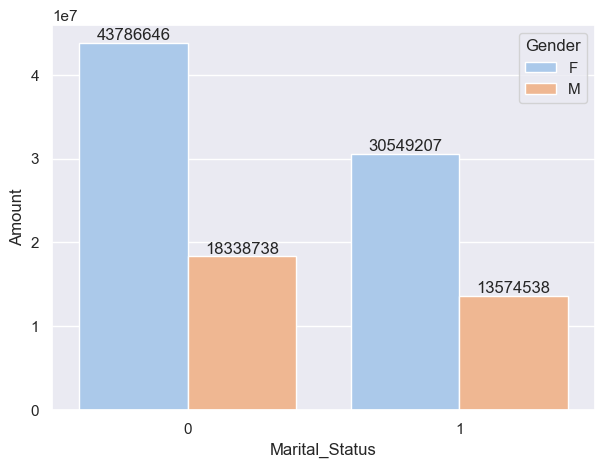

In [49]:
ms_gender=df.groupby(["Marital_Status","Gender"],as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)
sns.set(rc={"figure.figsize":(7,5)})
graph=sns.barplot(x="Marital_Status",y="Amount",data=ms_gender,hue="Gender",palette="pastel")
for bars in graph.containers:
    graph.bar_label(bars,fmt="%.0f")

#### The bar chart shows that unmarried females contribute the highest total sales among all marital status and gender groups, indicating that this group is the most significant in terms of revenue.

### **Distribution of Customers by Occupation**

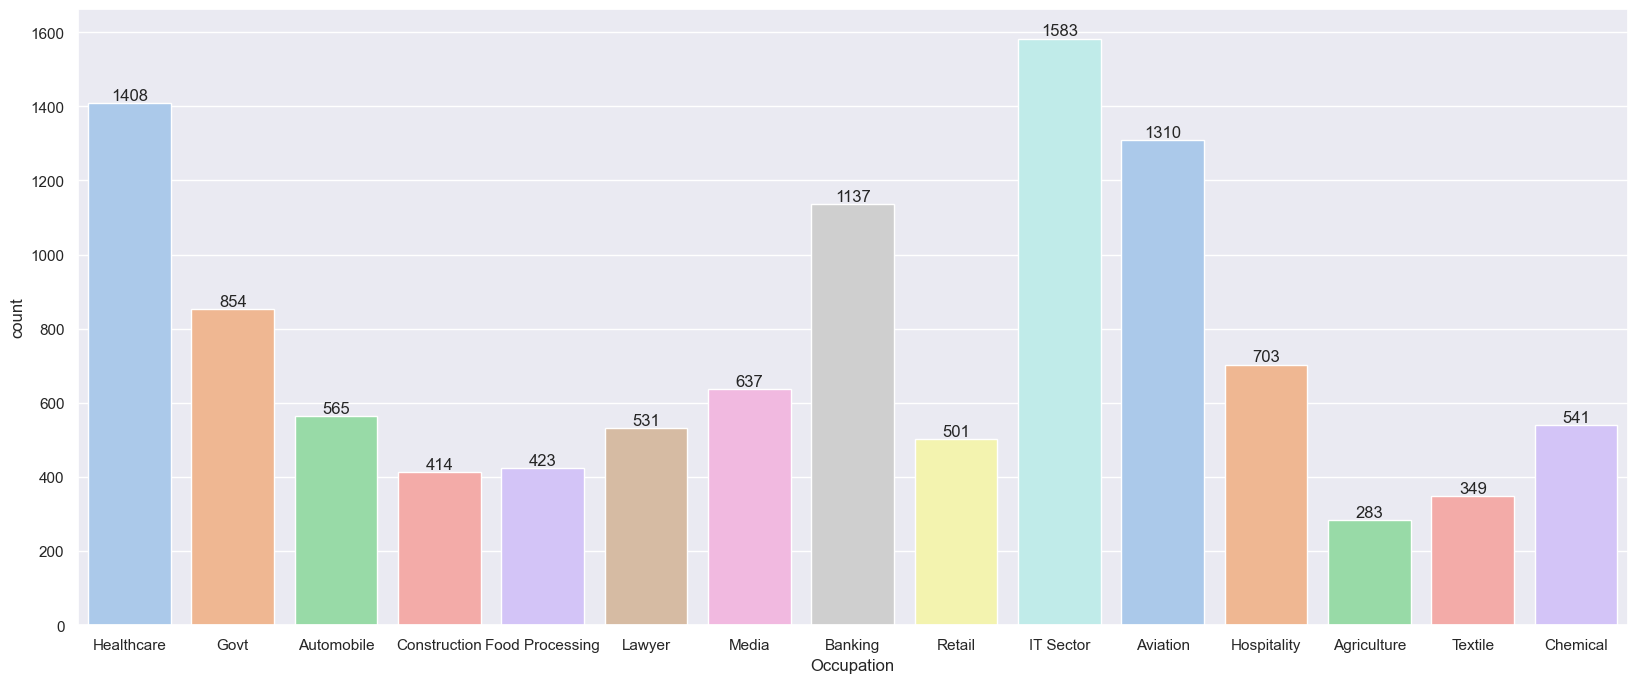

In [60]:
sns.set(rc={"figure.figsize":(20,8)})
occ=sns.countplot(x="Occupation",data=df,hue="Occupation",palette="pastel")
for bars in occ.containers:
    occ.bar_label(bars)

#### The bar chart shows that the IT sector has the highest number of customers among all occupations, indicating that most of the dataset’s customers are from the IT field.

### **Total Sales Amount by Occupation**

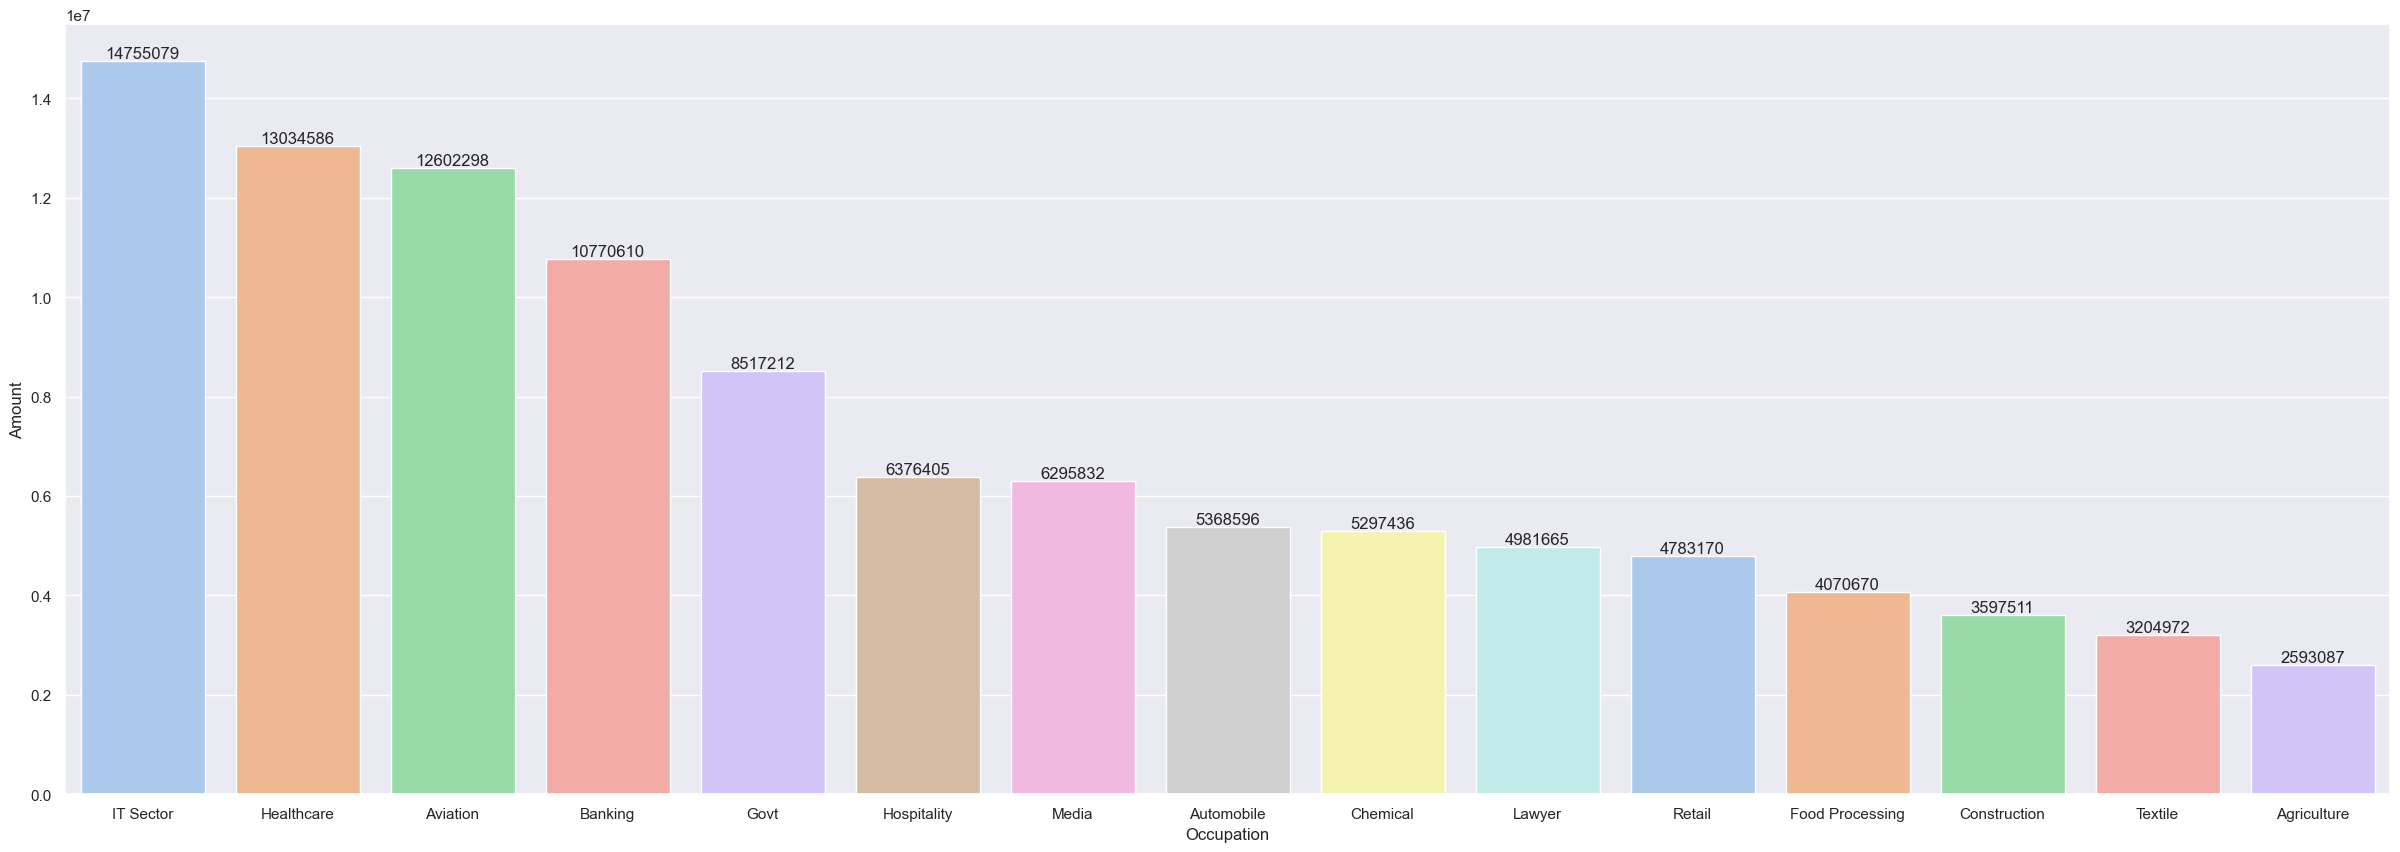

In [72]:
sales_occ=df.groupby(["Occupation"],as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)
sns.set(rc={"figure.figsize":(30,10)})
graph=sns.barplot(x="Occupation",y="Amount",data=sales_occ,hue="Occupation",palette="pastel")
for bars in graph.containers:
    graph.bar_label(bars,fmt="%.0f")

#### The bar chart shows that the IT sector has the highest total sales amount among all occupations, indicating that IT customers contribute the most to overall revenue.

### **Distribution of Customers by Product Category**

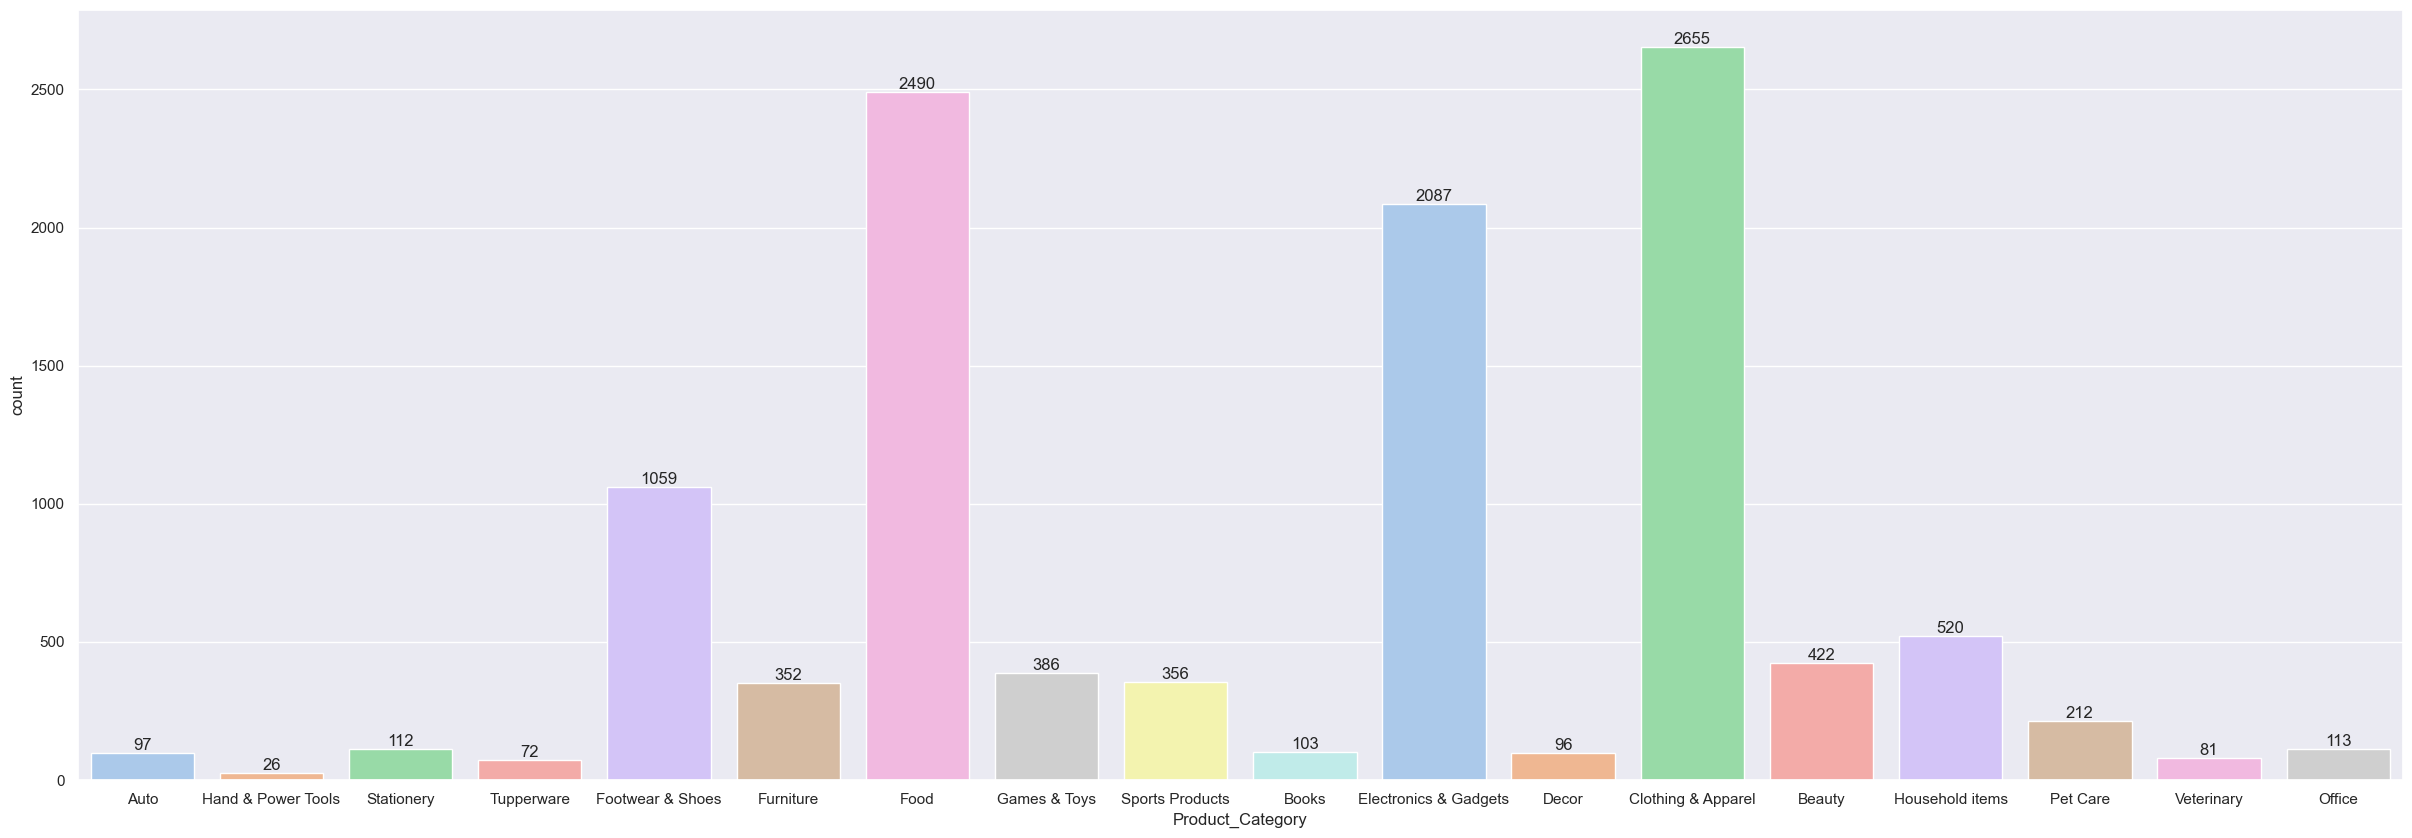

In [81]:
graph=sns.countplot(x="Product_Category",data=df,hue="Product_Category",palette="pastel")
sns.set(rc={"figure.figsize":(20,5)})
for bars in graph.containers:
    graph.bar_label(bars)

#### The bar chart shows that Clothing and Apparel has the highest number of orders, followed by Food, indicating that these two categories are the most popular among customers.

### **Top 10 Product Categories by Total Sales Amount**

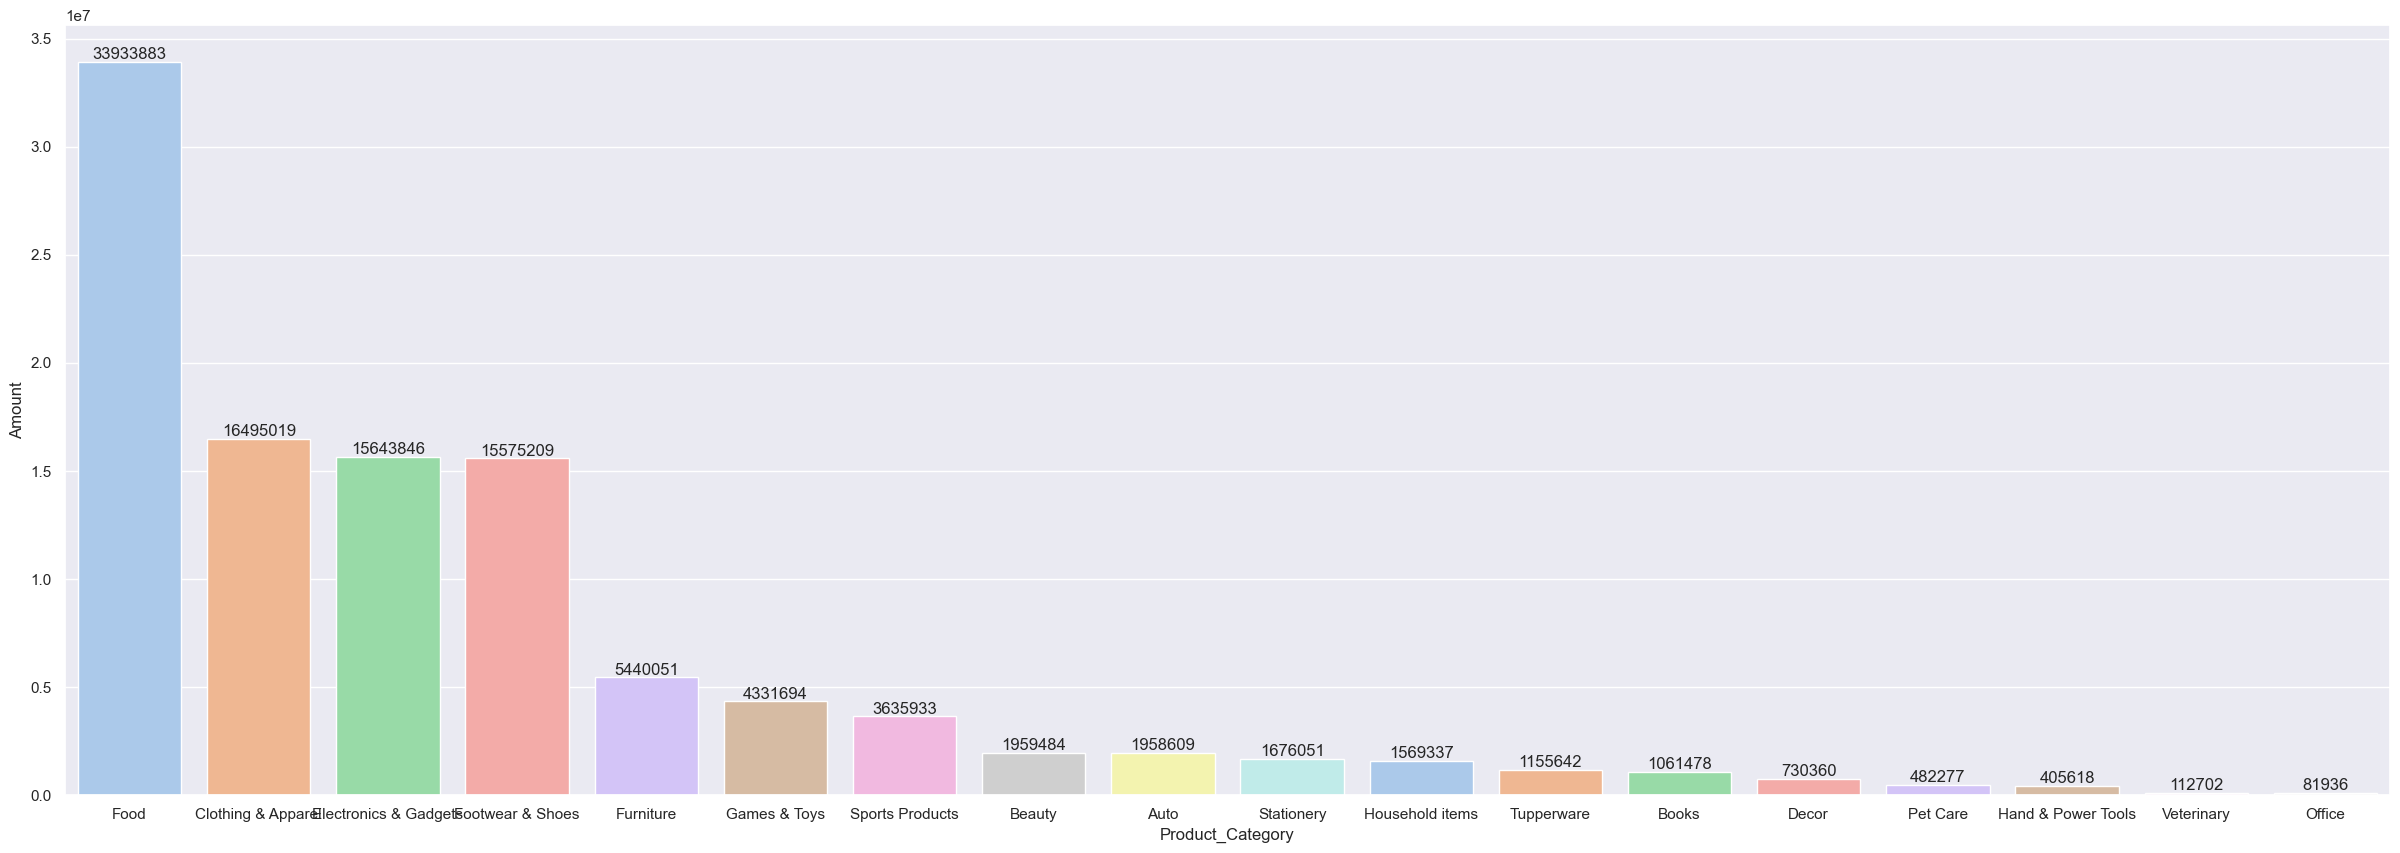

In [92]:
pc_sales=df.groupby(["Product_Category"],as_index=False)["Amount"].sum().sort_values(by="Amount",ascending=False)
sns.set(rc={"figure.figsize":(30,10)})
graph=sns.barplot(x="Product_Category",y="Amount",data=pc_sales,hue="Product_Category",palette="pastel")
for bars in graph.containers:
    graph.bar_label(bars,fmt="%.0f")

#### The bar chart shows that the Food category generates the highest total sales amount among all product categories, indicating that it is the most lucrative category in the dataset.

### **Top 10 Products by Number of Orders**

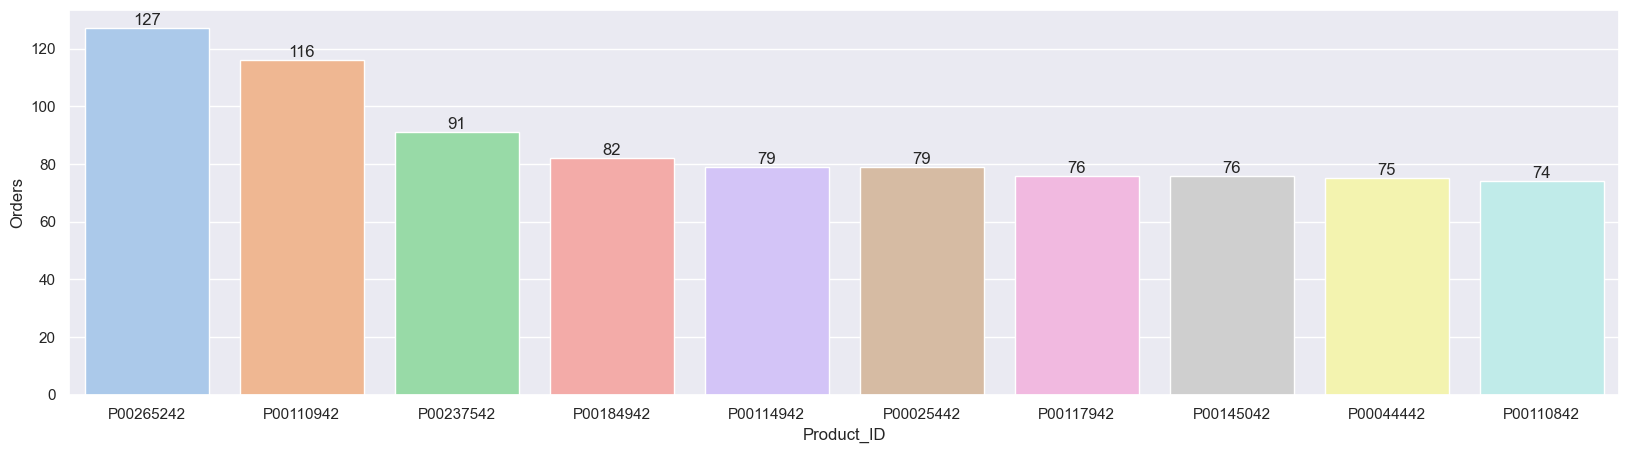

In [96]:
pi_orders=df.groupby(["Product_ID"],as_index=False)["Orders"].sum().sort_values(by="Orders",ascending=False).head(10)
sns.set(rc={"figure.figsize":(20,5)})
graph=sns.barplot(x="Product_ID",y="Orders",hue="Product_ID",data=pi_orders,palette="pastel")
for bars in graph.containers:
    graph.bar_label(bars)

#### The bar chart shows that products P00265242 and P00110942 have the highest number of orders, indicating that these are the most popular products among customers.

### **Correlation Heatmap of Numerical Features**

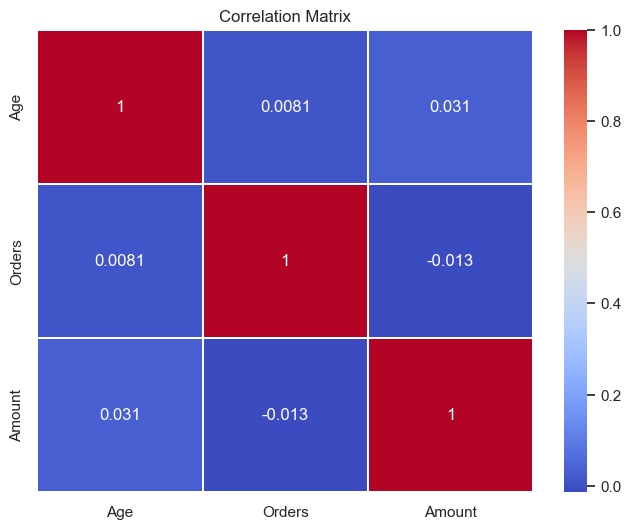

In [103]:
corr=df[["Age","Orders","Amount"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap="coolwarm",linewidths=0.2)
plt.title("Correlation Matrix")
plt.show()

### **Mapping Marital Status to Descriptive Labels**

In [105]:
df["Marital_Status_Label"]=df["Marital_Status"].map({0:"Unmarried",1:"Married"})
df[["Marital_Status_Label","Marital_Status"]].head()

,Marital_Status_Label,Marital_Status
0,Unmarried,0
1,Married,1
2,Married,1
3,Unmarried,0
4,Married,1


## **Conclusion**

Based on the Exploratory Data Analysis (EDA) of the Diwali Sales dataset, the following key insights have been identified:

* **Customer Demographics**
    * **Gender:** Women are the primary consumers, showing higher engagement and total spending compared to men.
    * **Age Group:** The most active shoppers belong to the **26-35 years** age bracket.
    * **Marital Status:** Married women form the largest and most influential purchasing segment.

* **Geographical and Occupational Trends**
    * **Top States:** The majority of orders and highest revenue are generated from **Uttar Pradesh, Maharashtra, and Karnataka**.
    * **Leading Sectors:** Consumers employed in the **Healthcare, IT Sector, and Aviation** industries demonstrate the highest purchasing power.

* **Product Performance**
    * **Top Categories:** **Food, Clothing & Apparel, and Electronics** are the most sought-after categories during the festive season.
    * **Inventory Insights:** Specific products (like Product ID P00265242) show high demand, indicating a preference for certain high-performing items within these categories.

* **Technical Enhancements (New Additions)**
    * **Feature Engineering:** Successfully processed the 'Marital_Status' column to improve data readability and categorical analysis.
    * **Correlation Analysis:** Implemented a **Heatmap** to visualize the relationships between numerical variables, providing a clearer understanding of spending drivers.

### **Final Summary**
The ideal target audience for maximizing Diwali sales consists of **married women aged 26-35 years** residing in **UP, Maharashtra, and Karnataka**, specifically those working in high-growth sectors like **Healthcare and IT**. Marketing strategies should focus on these segments with a primary emphasis on the **Food and Clothing** product lines.